In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Continue with your analysis
import matplotlib.pyplot as plt
import pandas as pd


# Reload the dataset if necessary
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data_csv = pd.read_csv(file_path, encoding='latin1')

Mounted at /content/drive


Data loaded successfully with shape: (640, 96)
Target variable 'B2' encoded successfully.
Calculating Correlation Analysis...


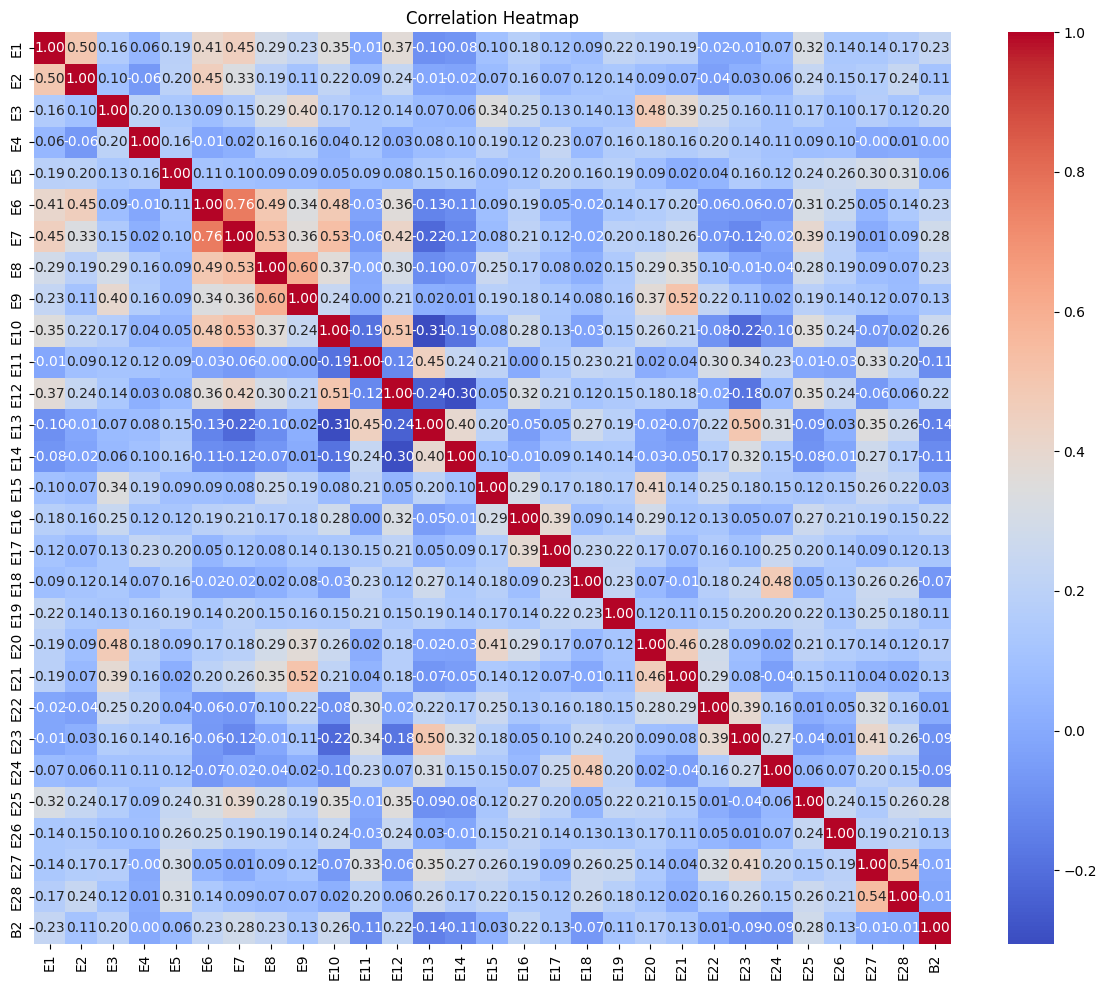

Correlation heatmap saved as 'correlation_heatmap.png'.
Calculating Mutual Information...


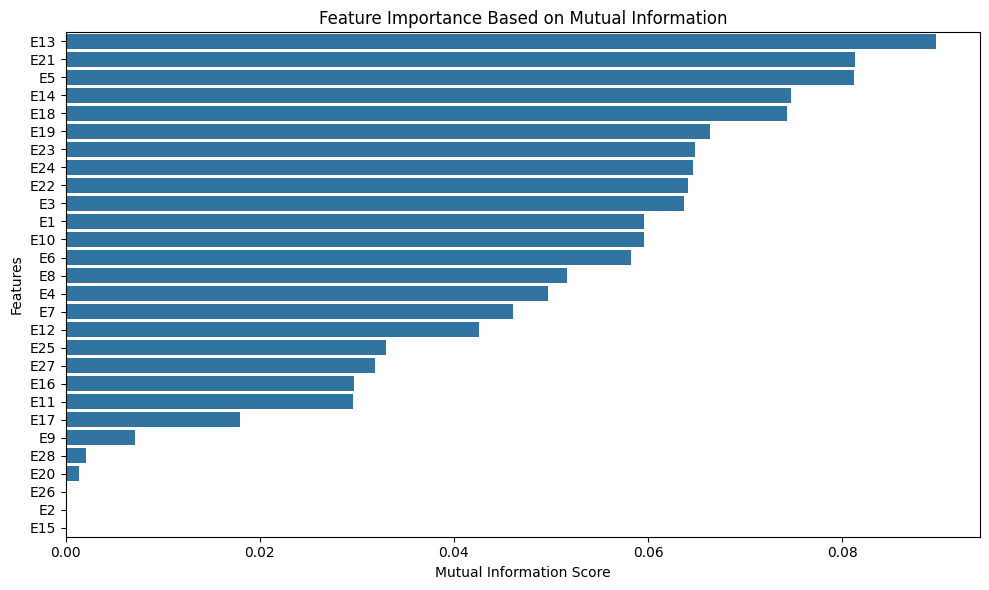

Mutual Information graph saved as 'mutual_information_importance.png'.
E13    0.089726
E21    0.081330
E5     0.081257
E14    0.074714
E18    0.074273
dtype: float64
Calculating Random Forest feature importance...


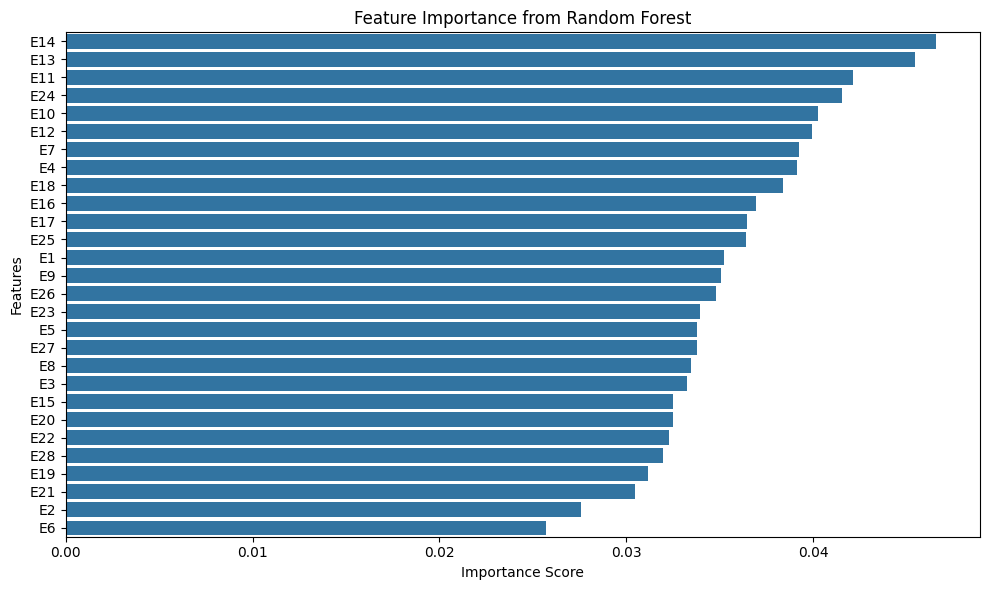

Random Forest graph saved as 'random_forest_importance.png'.
E14    0.046603
E13    0.045464
E11    0.042123
E24    0.041553
E10    0.040277
dtype: float64
Calculating XGBoost feature importance...


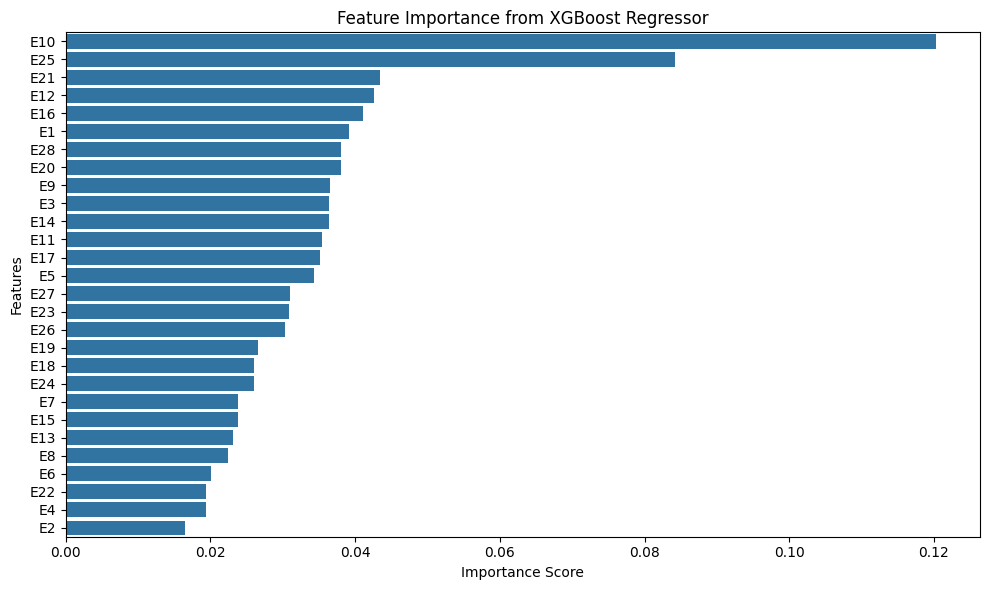

XGBoost graph saved as 'xgboost_importance.png'.
E10    0.120342
E25    0.084242
E21    0.043459
E12    0.042543
E16    0.041025
dtype: float32
Calculating Permutation Importance...


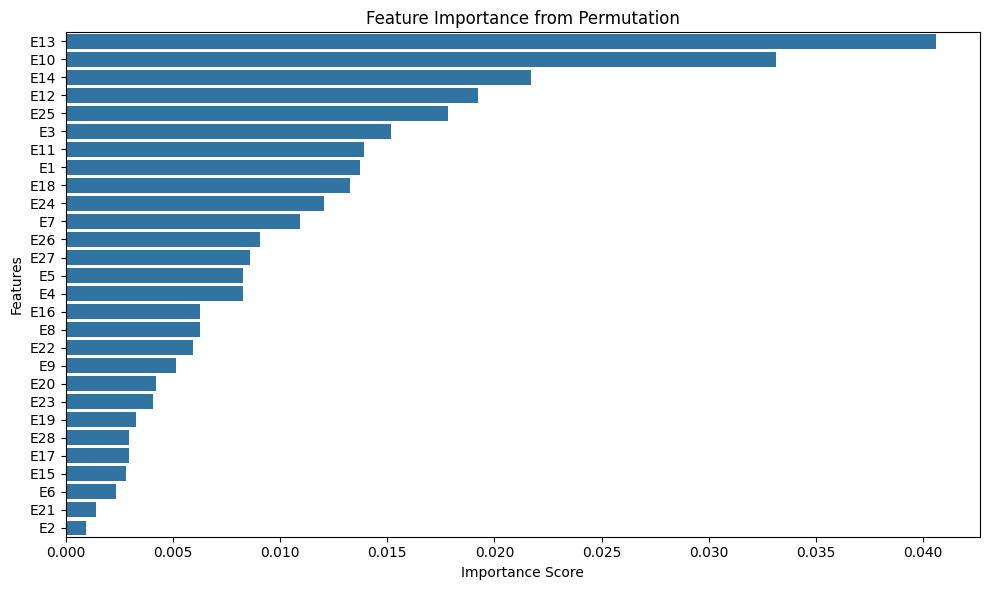

Permutation Importance graph saved as 'permutation_importance.png'.
Calculating SHAP values...


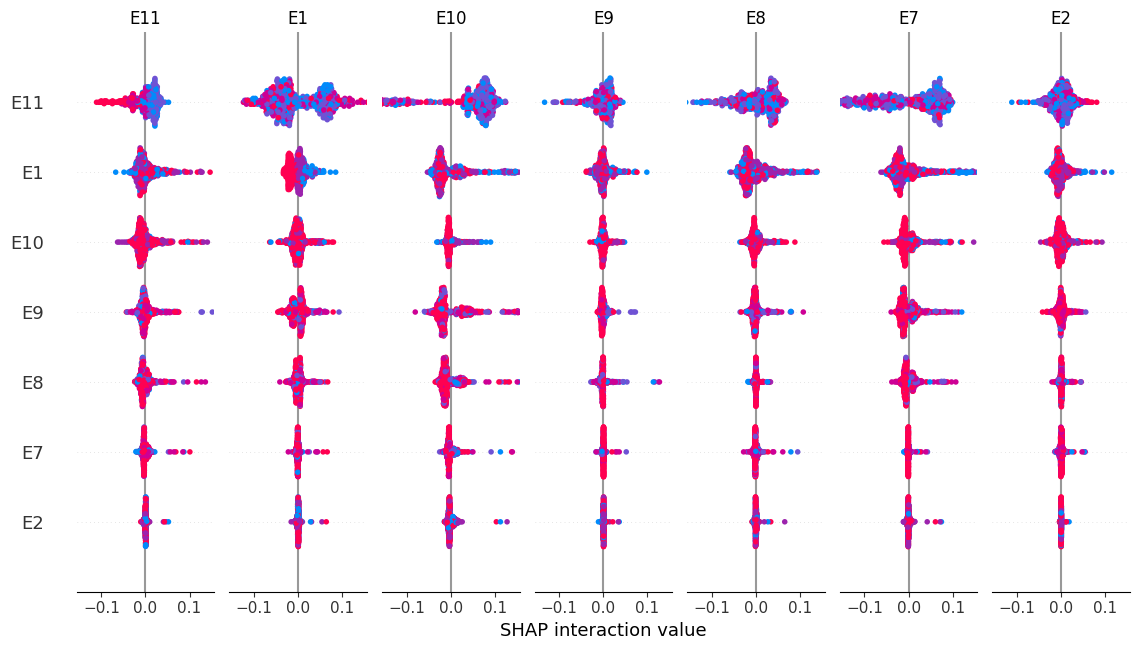

SHAP importance plot saved as 'shap_importance.png'.
Evaluating Feature Importance Stability...


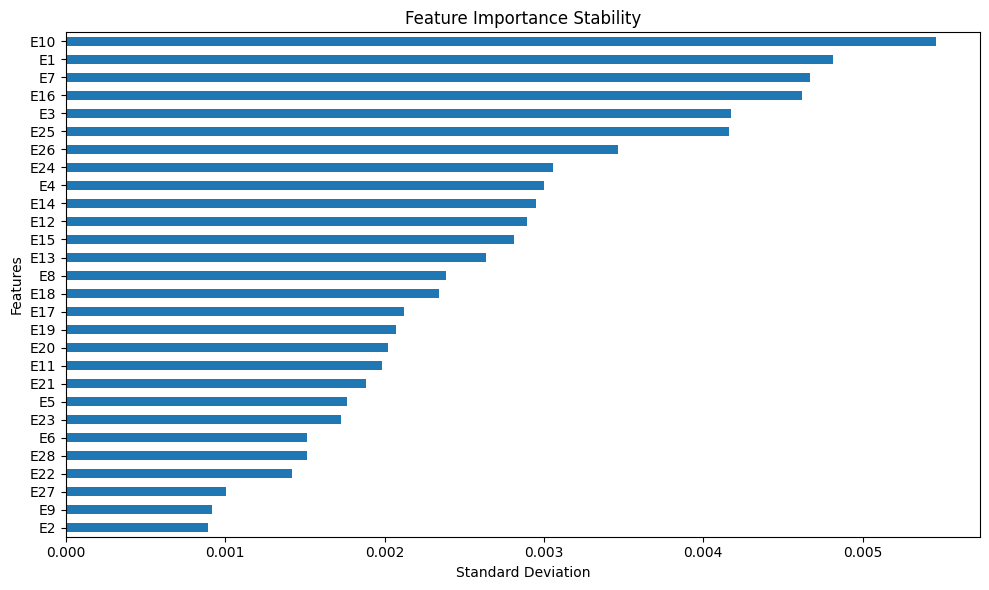

Feature importance stability plot saved as 'feature_importance_stability.png'.
Aggregating Rankings...


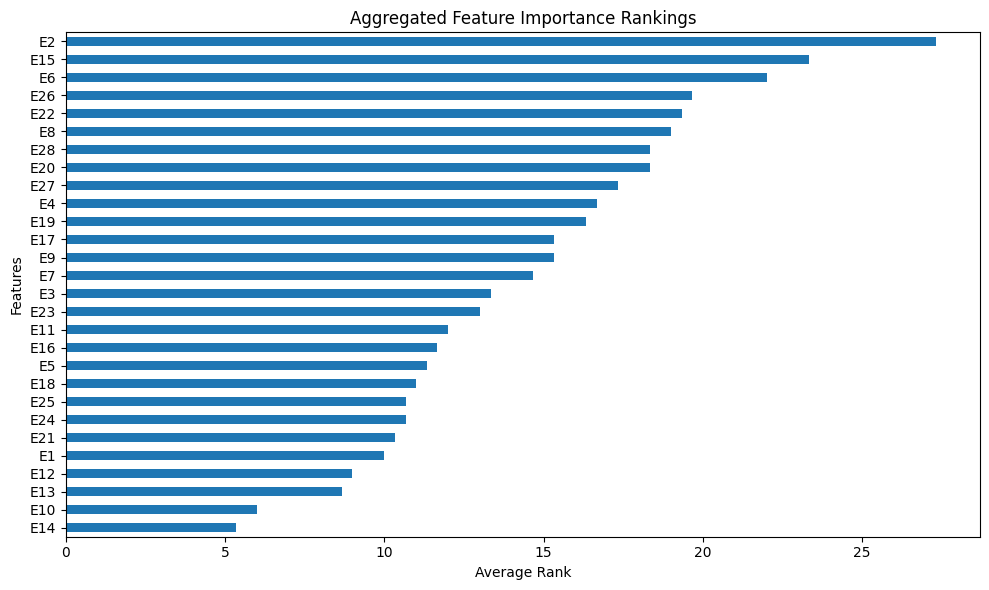

Aggregated feature importance plot saved as 'aggregated_importance.png'.


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def load_data(file_path, encoding='ISO-8859-1'):
    """
    Load the dataset and return it as a DataFrame.
    """
    try:
        data = pd.read_csv(file_path, encoding=encoding)
        print(f"Data loaded successfully with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(data, behavior_columns):
    """
    Preprocess the data: scale numeric columns and handle missing values.
    """
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(data[behavior_columns]), columns=behavior_columns)
    return X

def preprocess_target(data, target_col):
    """
    Convert string duration categories in the target column to numeric values.
    """
    # Define the mapping
    mapping = {
        "No self-isolation/social distancing": 0,
        "1 day": 1,
        "3 days": 3,
        "4 days": 4,
        "5 days": 5,
        "6 days": 6,
        "7 days": 7,
        "More than a week": 11,  # (8 + 14) / 2
        "More than 2 weeks": 18,  # (15 + 21) / 2
        "More than 3 weeks": 26,  # (22 + 30) / 2
        "More than a month": 32   # Approximation for open-ended range
    }


    if data[target_col].dtype == 'object':
        data[target_col] = data[target_col].map(mapping)

    # Identify unmapped values
    unmapped_values = data[target_col].isnull()
    if unmapped_values.sum() > 0:
        print(f"Warning: {unmapped_values.sum()} rows have unmapped values in '{target_col}'.")
        print("Unmapped values:")
        print(data.loc[unmapped_values, target_col])

    # Optionally drop rows with unmapped values
    data = data.dropna(subset=[target_col])
    return data[target_col]



def encode_target(data, target_col):
    """
    Encode the target variable using LabelEncoder.
    """
    label_encoder = LabelEncoder()
    return label_encoder.fit_transform(data[target_col])

def calculate_mutual_info(X, y, behavior_columns):
    """
    Calculate and visualize Mutual Information scores.
    """
    mutual_info = mutual_info_classif(X, y, discrete_features=False, n_neighbors=5)
    mi_scores = pd.Series(mutual_info, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=mi_scores.values, y=mi_scores.index)
    plt.title('Feature Importance Based on Mutual Information')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('mutual_information_importance.png')
    plt.show()
    print("Mutual Information graph saved as 'mutual_information_importance.png'.")
    return mi_scores

def calculate_random_forest_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using Random Forest.
    """
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('random_forest_importance.png')
    plt.show()
    print("Random Forest graph saved as 'random_forest_importance.png'.")
    return feature_importances

def calculate_xgboost_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using XGBoost Regressor.
    """
    model = XGBRegressor(eval_metric='rmse', n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from XGBoost Regressor')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('xgboost_importance.png')
    plt.show()
    print("XGBoost graph saved as 'xgboost_importance.png'.")
    return feature_importances

def calculate_permutation_importance(model, X, y, behavior_columns):
    """
    Calculate Permutation Importance after fitting a model.
    """
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importances = pd.Series(result.importances_mean, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=perm_importances.values, y=perm_importances.index)
    plt.title('Feature Importance from Permutation')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('permutation_importance.png')
    plt.show()
    print("Permutation Importance graph saved as 'permutation_importance.png'.")
    return perm_importances

def calculate_correlation(data, target_col):
    """
    Calculate and visualize the correlation matrix.
    """
    if target_col not in data.columns:
        raise KeyError(f"{target_col} not found in the dataset.")
    corr_matrix = data.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
    print("Correlation heatmap saved as 'correlation_heatmap.png'.")

def calculate_shap_importance(X, y):
    """
    Calculate and visualize SHAP values.
    """
    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig('shap_importance.png')
    plt.show()
    print("SHAP importance plot saved as 'shap_importance.png'.")

def evaluate_feature_stability(X, y, behavior_columns, n_splits=5):
    """
    Evaluate feature importance stability across multiple splits.
    """
    rf_importances = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X):
        model = RandomForestClassifier(random_state=42)
        model.fit(X.iloc[train_index], y[train_index])
        feature_importances = pd.Series(model.feature_importances_, index=behavior_columns)
        rf_importances.append(feature_importances)
    stability = pd.concat(rf_importances, axis=1).std(axis=1)
    plt.figure(figsize=(10, 6))
    stability.sort_values().plot(kind='barh')
    plt.title('Feature Importance Stability')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('feature_importance_stability.png')
    plt.show()
    print("Feature importance stability plot saved as 'feature_importance_stability.png'.")
    return stability

def aggregate_rankings(mi_scores, rf_importances, xgb_importances):
    """
    Aggregate rankings from different methods.
    """
    combined_rankings = (
        mi_scores.rank(ascending=False) +
        rf_importances.rank(ascending=False) +
        xgb_importances.rank(ascending=False)
    ) / 3
    combined_rankings = combined_rankings.sort_values()
    plt.figure(figsize=(10, 6))
    combined_rankings.plot(kind='barh')
    plt.title('Aggregated Feature Importance Rankings')
    plt.xlabel('Average Rank')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('aggregated_importance.png')
    plt.show()
    print("Aggregated feature importance plot saved as 'aggregated_importance.png'.")
    return combined_rankings

def main(data_path, target_col, behavior_prefix='E'):
    """
    Main function to execute the workflow.
    """
    data = load_data(data_path)
    if data is None:
        return

    # Extract relevant columns
    behavior_columns = [col for col in data.columns if col.startswith(behavior_prefix)]

    # Convert target column to numeric
    data[target_col] = preprocess_target(data, target_col)
    if data[target_col].isnull().any():
        raise ValueError("Some target values couldn't be mapped to numeric values. Please check the mapping.")

    X = preprocess_data(data, behavior_columns)
    y = data[target_col]

    print(f"Target variable '{target_col}' encoded successfully.")

    # Correlation Analysis
    print("Calculating Correlation Analysis...")
    calculate_correlation(data[behavior_columns + [target_col]], target_col)

    # Calculate Mutual Information
    print("Calculating Mutual Information...")
    mi_scores = calculate_mutual_info(X, y, behavior_columns)
    print(mi_scores.head())

    # Random Forest Importance
    print("Calculating Random Forest feature importance...")
    rf_importances = calculate_random_forest_importance(X, y, behavior_columns)
    print(rf_importances.head())

    # XGBoost Importance
    print("Calculating XGBoost feature importance...")
    xgb_importances = calculate_xgboost_importance(X, y, behavior_columns)
    print(xgb_importances.head())

    # Calculate Permutation Importance
    print("Calculating Permutation Importance...")
    calculate_permutation_importance(RandomForestClassifier(random_state=42).fit(X, y), X, y, behavior_columns)

    # SHAP Values
    print("Calculating SHAP values...")
    calculate_shap_importance(X, y)

    # Feature Stability
    print("Evaluating Feature Importance Stability...")
    evaluate_feature_stability(X, y, behavior_columns)

    # Aggregated Rankings
    print("Aggregating Rankings...")
    aggregate_rankings(mi_scores, rf_importances, xgb_importances)

# Execute the main function
if __name__ == "__main__":
    data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update the file path if necessary
    target_col = 'B2'  # Target variable column
    main(data_path, target_col)



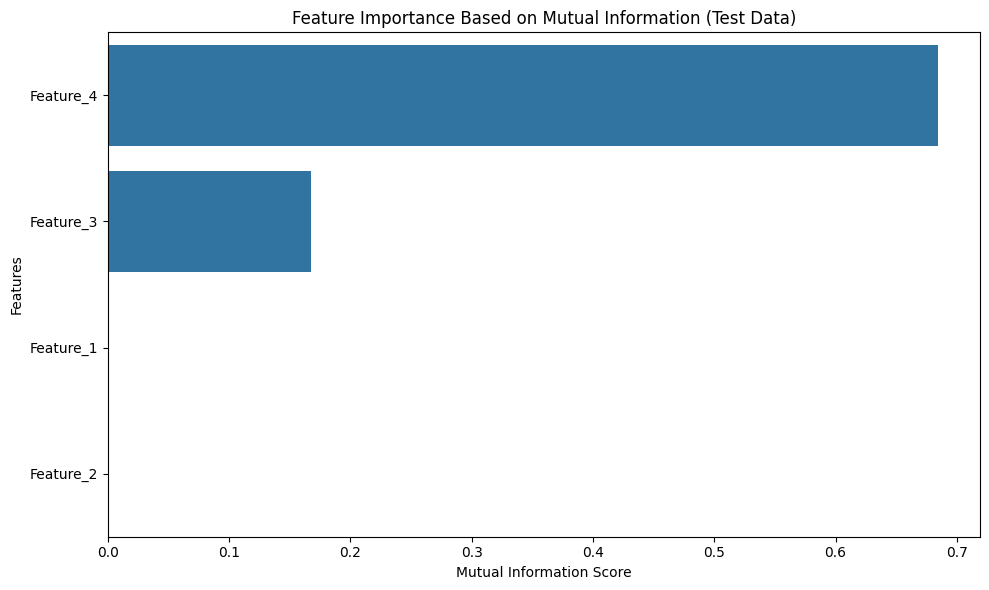

Mutual Information Scores (Test Data):
Feature_4    0.684835
Feature_3    0.167221
Feature_1    0.000000
Feature_2    0.000000
dtype: float64


In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
n_samples = 1000

# Features
X_test = pd.DataFrame({
    'Feature_1': np.random.uniform(0, 1, n_samples),  # Weakly correlated with y
    'Feature_2': np.random.uniform(0, 1, n_samples),  # Uncorrelated with y
    'Feature_3': np.random.randint(0, 2, n_samples),  # Strongly correlated with y
    'Feature_4': np.random.randint(0, 10, n_samples)  # Moderately correlated with y
})

# Target variable (y)
y_test = (X_test['Feature_3'] + 0.3 * X_test['Feature_4'] +
          0.1 * np.random.normal(0, 1, n_samples)).round().astype(int)

# Calculate Mutual Information
mi_scores = mutual_info_classif(X_test, y_test, discrete_features='auto')
mi_scores = pd.Series(mi_scores, index=X_test.columns).sort_values(ascending=False)

# Visualize Mutual Information
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores.values, y=mi_scores.index)
plt.title('Feature Importance Based on Mutual Information (Test Data)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print scores
print("Mutual Information Scores (Test Data):")
print(mi_scores)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:25:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
<ipython-input-18-d2da01cb8c46>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Method', data=d6_importances, palette='viridis')


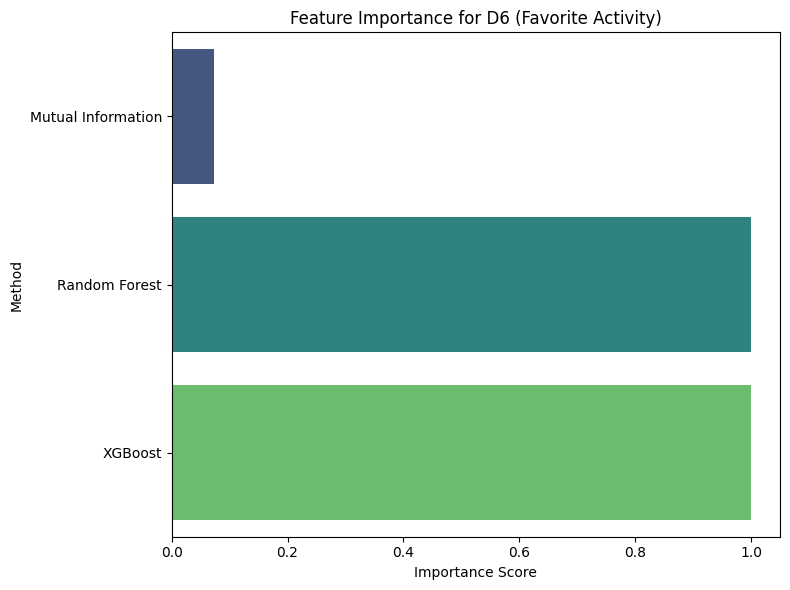

               Method  Importance
0  Mutual Information    0.072329
1       Random Forest    1.000000
2             XGBoost    1.000000


In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update this with the actual path to your dataset
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Ensure the target column (B2) is mapped to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,  # (8 + 14) / 2
    "More than 2 weeks": 18,  # (15 + 21) / 2
    "More than 3 weeks": 26,  # (22 + 30) / 2
    "More than a month": 32   # Approximation for open-ended range
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows where B2 mapping failed

# Encode behavioral columns and D6
behavioral_columns = [col for col in data.columns if col.startswith('E')]
data['D6_encoded'] = LabelEncoder().fit_transform(data['D6'])

# Create feature matrix (X) and target variable (y)
X = pd.DataFrame(StandardScaler().fit_transform(data[behavioral_columns + ['D6_encoded']]),
                 columns=behavioral_columns + ['D6_encoded'])
y = data['B2_numeric']

# Normalize the target variable to consecutive integers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_normalized = label_encoder.fit_transform(y)  # Maps [0, 1, 3, 4, ...] to [0, 1, 2, 3, ...]

# Re-run XGBoost model for D6
xgb_model_d6 = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model_d6.fit(X[['D6_encoded']], y_normalized)
xgb_importance_d6 = xgb_model_d6.feature_importances_[0]


# Use XGBoost Regressor
xgb_model_d6 = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_model_d6.fit(X[['D6_encoded']], y)
xgb_importance_d6 = xgb_model_d6.feature_importances_[0]



# Normalize the target classes (if using classification)
y_normalized = LabelEncoder().fit_transform(y)

# Calculate Mutual Information for D6
mi_d6 = mutual_info_classif(X[['D6_encoded']], y, discrete_features=False)[0]

# Train Random Forest for D6
rf_model_d6 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_d6.fit(X[['D6_encoded']], y)
rf_importance_d6 = rf_model_d6.feature_importances_[0]

# Train XGBoost for D6 (using normalized classes for classification or regression)
xgb_model_d6 = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model_d6.fit(X[['D6_encoded']], y_normalized)
xgb_importance_d6 = xgb_model_d6.feature_importances_[0]



# Create a DataFrame for the importances
d6_importances = pd.DataFrame({
    'Method': ['Mutual Information', 'Random Forest', 'XGBoost'],
    'Importance': [mi_d6, rf_importance_d6, xgb_importance_d6]
})

# Updated bar plot for D6 importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Method', data=d6_importances, palette='viridis')
plt.title('Feature Importance for D6 (Favorite Activity)')
plt.xlabel('Importance Score')
plt.ylabel('Method')
plt.tight_layout()
plt.savefig('d6_importance_refined.png')
plt.show()


print(d6_importances)



In [19]:
# Display the most frequently used activity in D6
most_used_activity = data['D6'].value_counts().idxmax()
most_used_activity_count = data['D6'].value_counts().max()

print("Most used activity:", most_used_activity)
print("Count:", most_used_activity_count)

# Display full frequency distribution
print("\nActivity frequency distribution:")
print(data['D6'].value_counts())


Most used activity: Fishing
Count: 150

Activity frequency distribution:
D6
Fishing                                        150
Terraforming                                   131
Planting trees/flowers                         128
Catching bugs                                   74
Talking to villagers                             6
                                              ... 
Visiting other islands                           1
Doing daily chores and talking to villagers      1
Shopping and visiting friends' islands           1
Name: count, Length: 134, dtype: int64


<ipython-input-20-81af5f9ee3d5>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_activities.values, y=top_activities.index, palette='viridis')


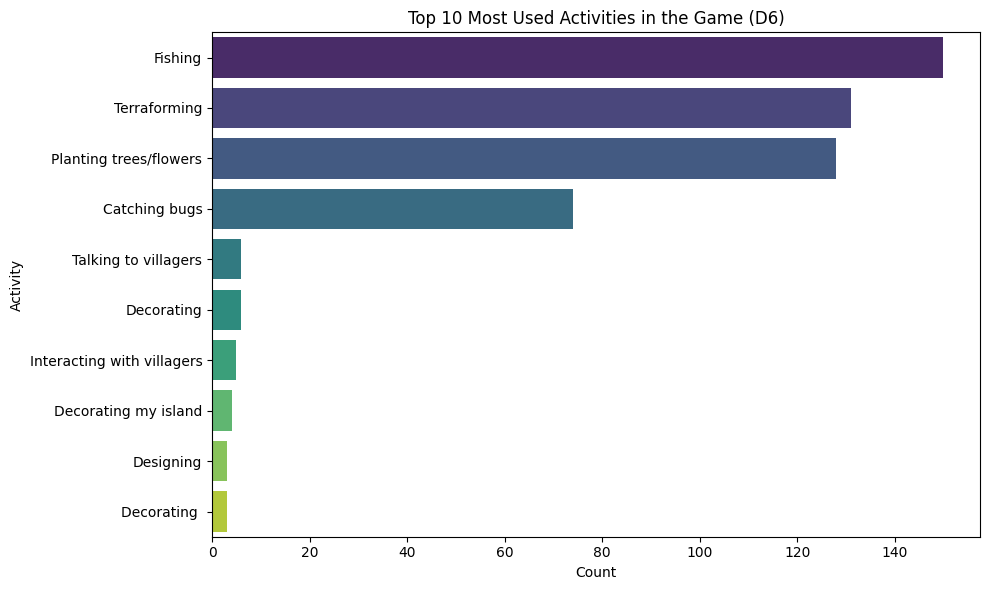

In [20]:
# Plot the top 10 most frequent activities
top_activities = data['D6'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_activities.values, y=top_activities.index, palette='viridis')
plt.title('Top 10 Most Used Activities in the Game (D6)')
plt.xlabel('Count')
plt.ylabel('Activity')
plt.tight_layout()
plt.savefig('top_activities_d6.png')
plt.show()


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Feature and Target Preparation
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = pd.DataFrame(StandardScaler().fit_transform(data[behavioral_columns]), columns=behavioral_columns)
y = data['B2_numeric']

# 1. Calculate Mutual Information Scores
mi_scores = mutual_info_classif(X, y, discrete_features=False)
mi_scores_series = pd.Series(mi_scores, index=behavioral_columns).sort_values(ascending=False)

# 2. Calculate Random Forest Importance
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X, y)
rf_importances_series = pd.Series(rf_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# 3. Calculate XGBoost Importance
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X, y)
xgb_importances_series = pd.Series(xgb_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# Aggregate Rankings from All Methods
rankings = pd.DataFrame({
    'Mutual Information': mi_scores_series.rank(ascending=False),
    'Random Forest': rf_importances_series.rank(ascending=False),
    'XGBoost': xgb_importances_series.rank(ascending=False)
})
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values(by='Average Rank')

# Display Results
print("Top Features by Aggregated Ranking:")
print(rankings.head())

# Visualization of Rankings
plt.figure(figsize=(10, 8))
rankings['Average Rank'].plot(kind='barh', title="Aggregated Feature Importance Rankings", xlabel="Features", ylabel="Average Rank")
plt.tight_layout()
plt.savefig('aggregated_importance_ranking.png')
plt.show()


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10], got [ 0  1  3  4  5  6  7 11 18 26 32]

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:41:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Top Features by Aggregated Ranking:
     Mutual Information  Random Forest  XGBoost  Average Rank
E13                 1.0            2.0      3.0      2.000000
E14                 2.0            1.0      4.0      2.333333
E10                 5.0            5.0      1.0      3.666667
E12                 6.0            6.0      8.0      6.666667
E25                 8.0           12.0      2.0      7.333333


<ipython-input-22-c35f1dd29798>:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rankings['Average Rank'], y=rankings.index, palette='viridis')


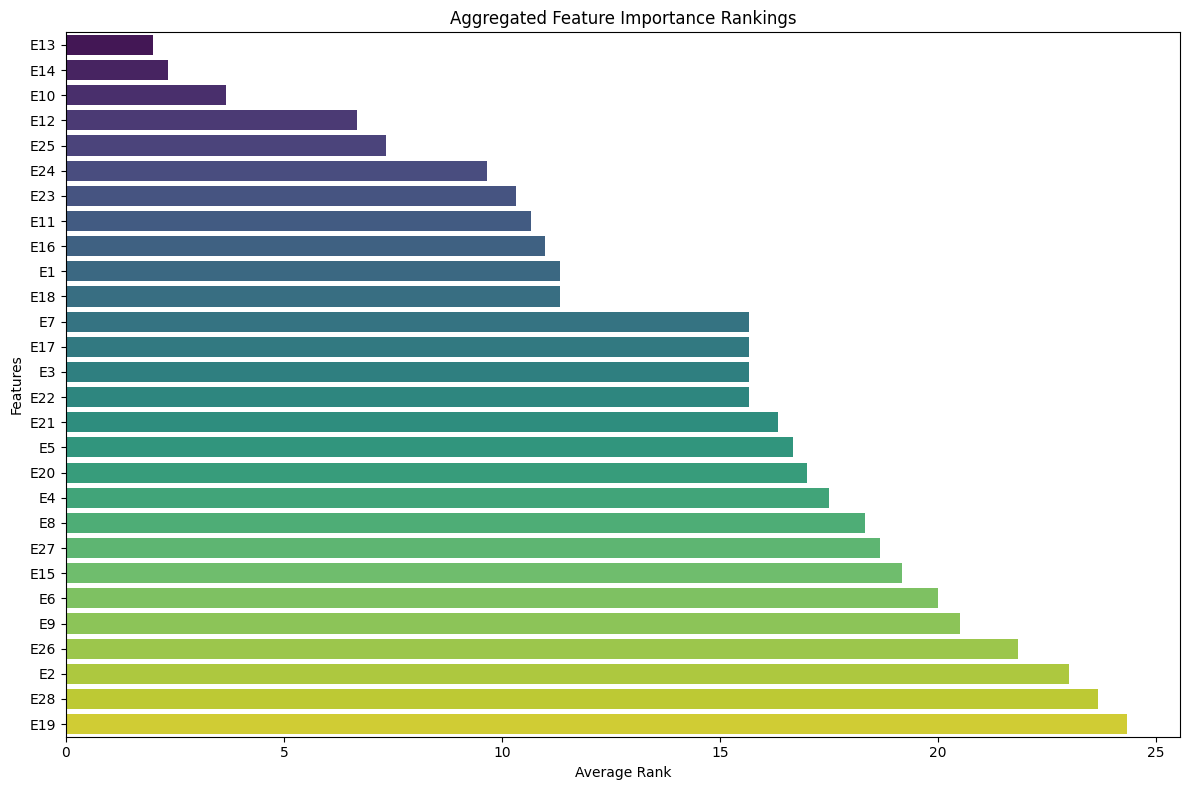

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update with your file path
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Map the target column (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows where mapping failed

# Define feature matrix (X) and target variable (y)
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = pd.DataFrame(StandardScaler().fit_transform(data[behavioral_columns]), columns=behavioral_columns)
y = data['B2_numeric']

# Normalize the target variable for classification
label_encoder = LabelEncoder()
y_normalized = label_encoder.fit_transform(y)

# 1. Calculate Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=False)
mi_scores_series = pd.Series(mi_scores, index=behavioral_columns).sort_values(ascending=False)

# 2. Calculate Random Forest Importance
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X, y)
rf_importances_series = pd.Series(rf_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# 3. Calculate XGBoost Importance
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X, y_normalized)
xgb_importances_series = pd.Series(xgb_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# Aggregate Rankings
rankings = pd.DataFrame({
    'Mutual Information': mi_scores_series.rank(ascending=False),
    'Random Forest': rf_importances_series.rank(ascending=False),
    'XGBoost': xgb_importances_series.rank(ascending=False)
})
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values(by='Average Rank')

# Display Top Features
print("Top Features by Aggregated Ranking:")
print(rankings.head())

# Visualization of Rankings
plt.figure(figsize=(12, 8))
sns.barplot(x=rankings['Average Rank'], y=rankings.index, palette='viridis')
plt.title("Aggregated Feature Importance Rankings")
plt.xlabel("Average Rank")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('aggregated_importance_ranking.png')
plt.show()


In [23]:
# Display full aggregated rankings
print("Full Aggregated Feature Importance Rankings:")
print(rankings)


Full Aggregated Feature Importance Rankings:
     Mutual Information  Random Forest  XGBoost  Average Rank
E13                 1.0            2.0      3.0      2.000000
E14                 2.0            1.0      4.0      2.333333
E10                 5.0            5.0      1.0      3.666667
E12                 6.0            6.0      8.0      6.666667
E25                 8.0           12.0      2.0      7.333333
E24                11.0            4.0     14.0      9.666667
E23                 4.0           16.0     11.0     10.333333
E11                13.0            3.0     16.0     10.666667
E16                16.0           10.0      7.0     11.000000
E1                 15.0           13.0      6.0     11.333333
E18                12.0            9.0     13.0     11.333333
E7                 18.0            7.0     22.0     15.666667
E17                21.0           11.0     15.0     15.666667
E3                 22.0           20.0      5.0     15.666667
E22                 7.0  

Counts for E1:
E1
3    270
4    253
2    112
1      5
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


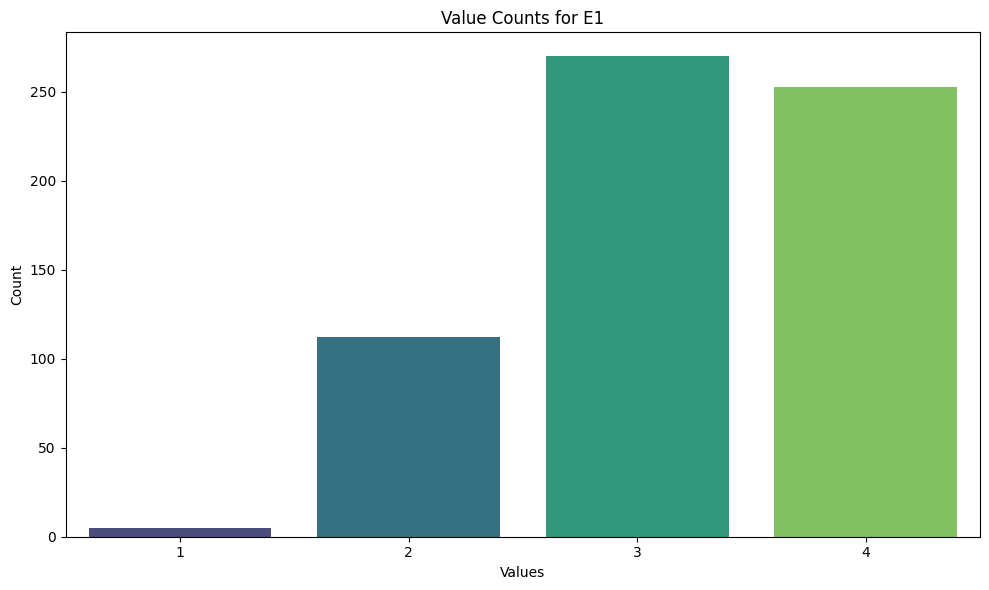

Counts for E2:
E2
4    283
3    241
2    105
1     11
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


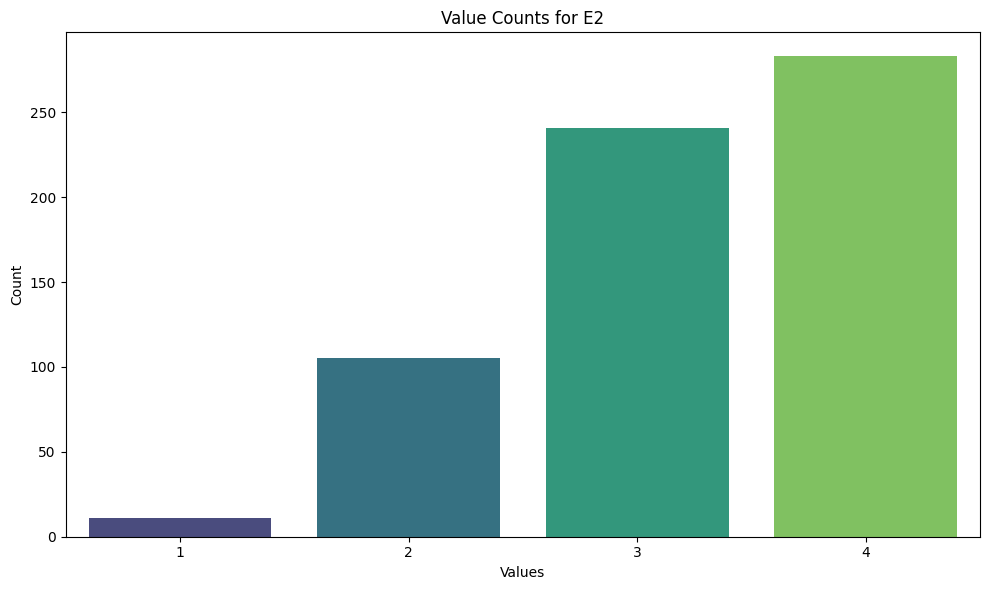

Counts for E3:
E3
3    262
4    253
2    116
1      9
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


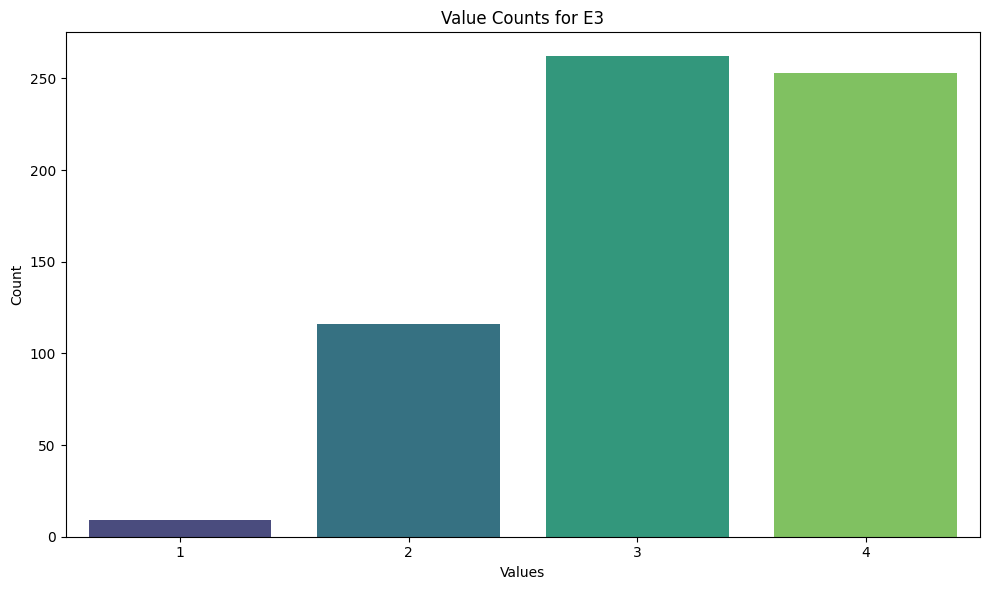

Counts for E4:
E4
3    221
4    216
2    163
1     40
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


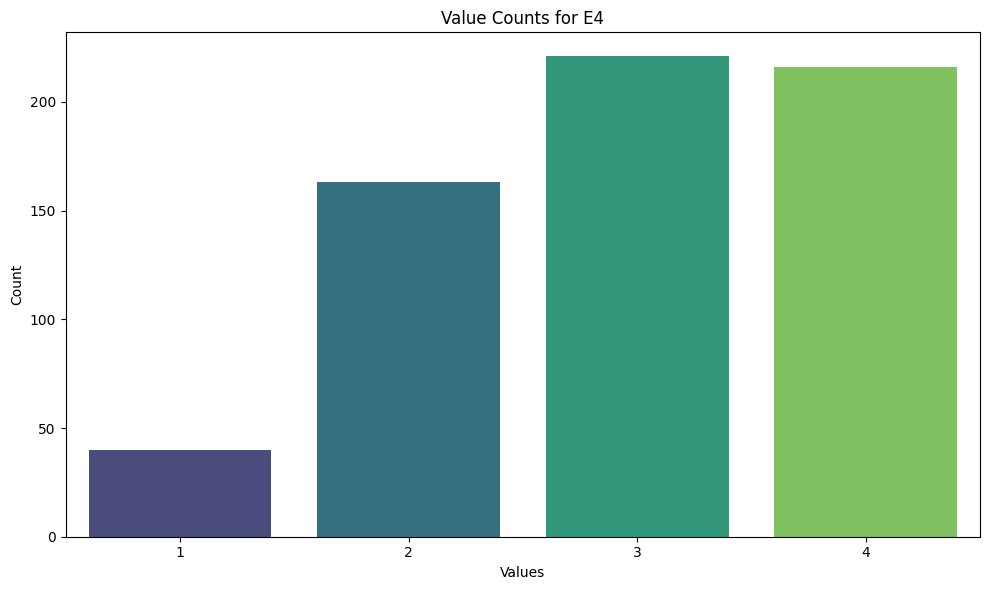

Counts for E5:
E5
3    279
2    194
4    136
1     31
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


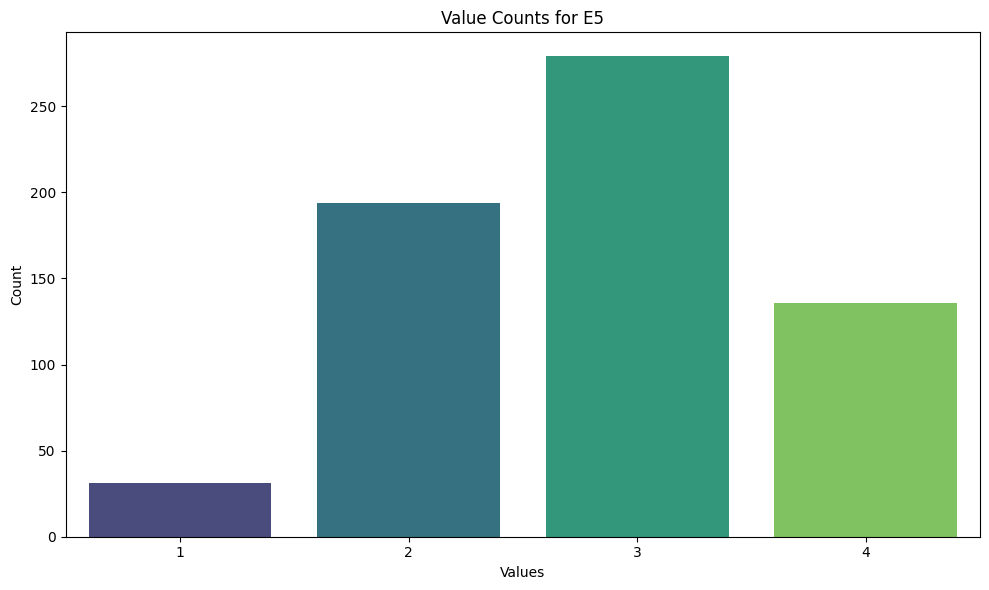

Counts for E6:
E6
5    367
4    175
3     66
2     21
1     11
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


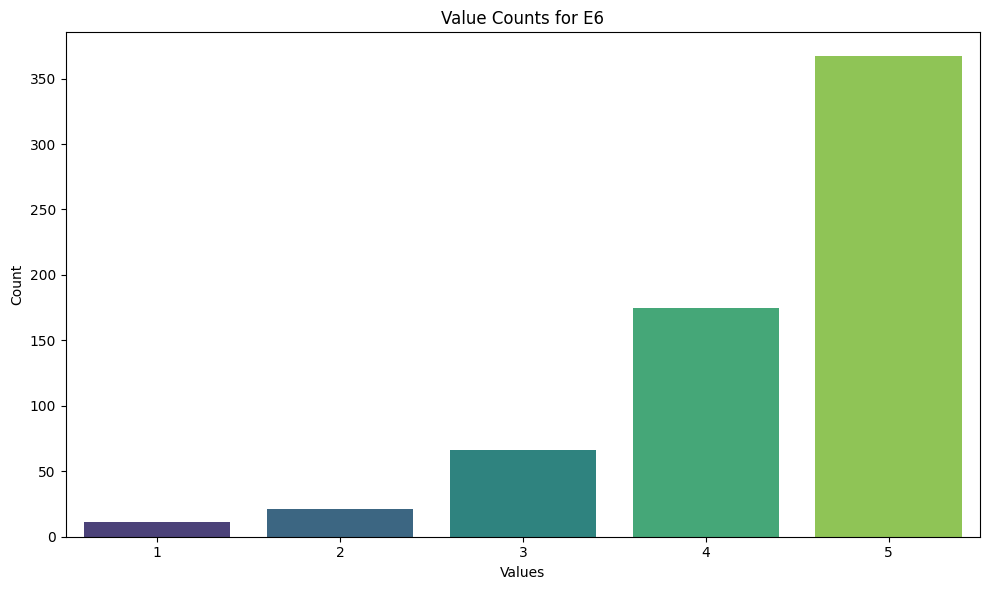

Counts for E7:
E7
5    358
4    154
3     75
2     41
1     12
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


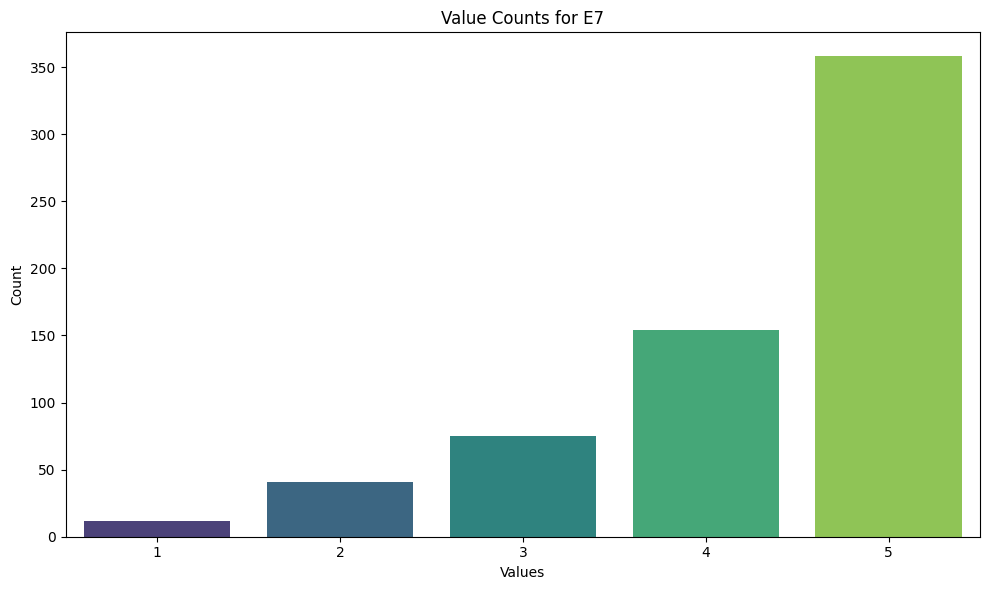

Counts for E8:
E8
5    336
4    159
3     99
2     36
1     10
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


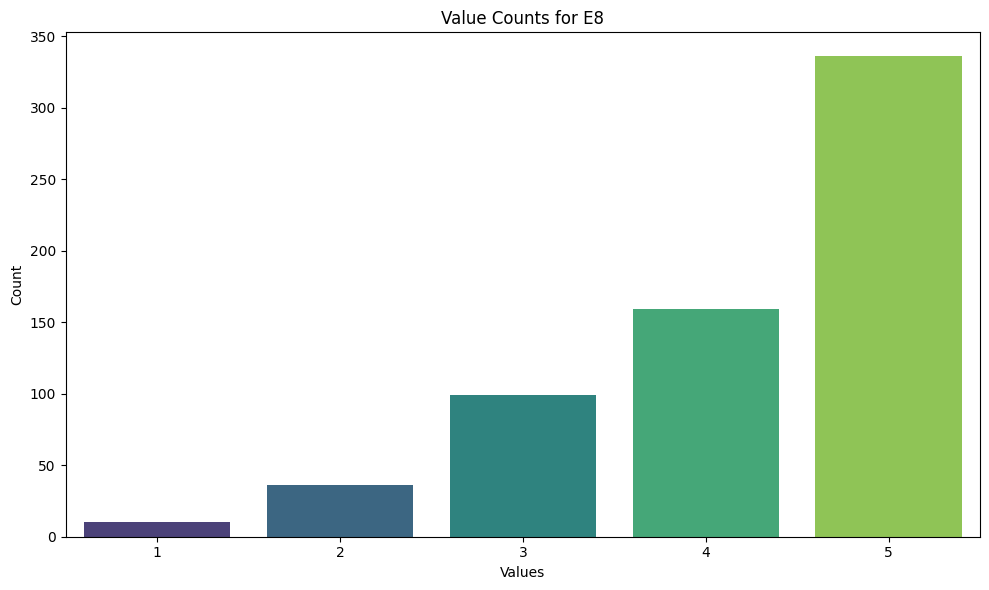

Counts for E9:
E9
5    323
4    173
3     95
2     37
1     12
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


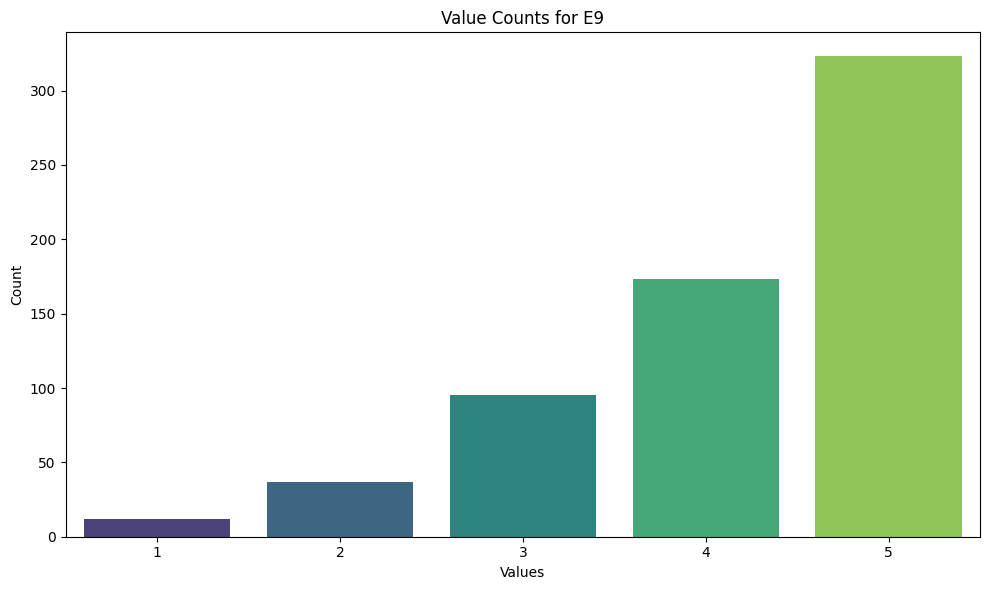

Counts for E10:
E10
4    459
3    123
2     52
1      6
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


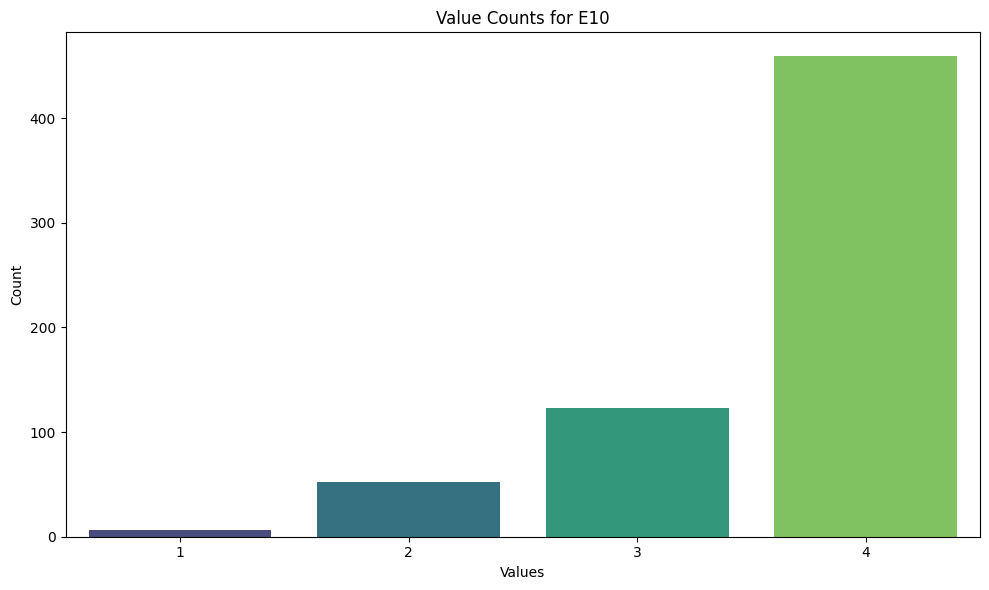

Counts for E11:
E11
2    243
1    161
3    156
4     80
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


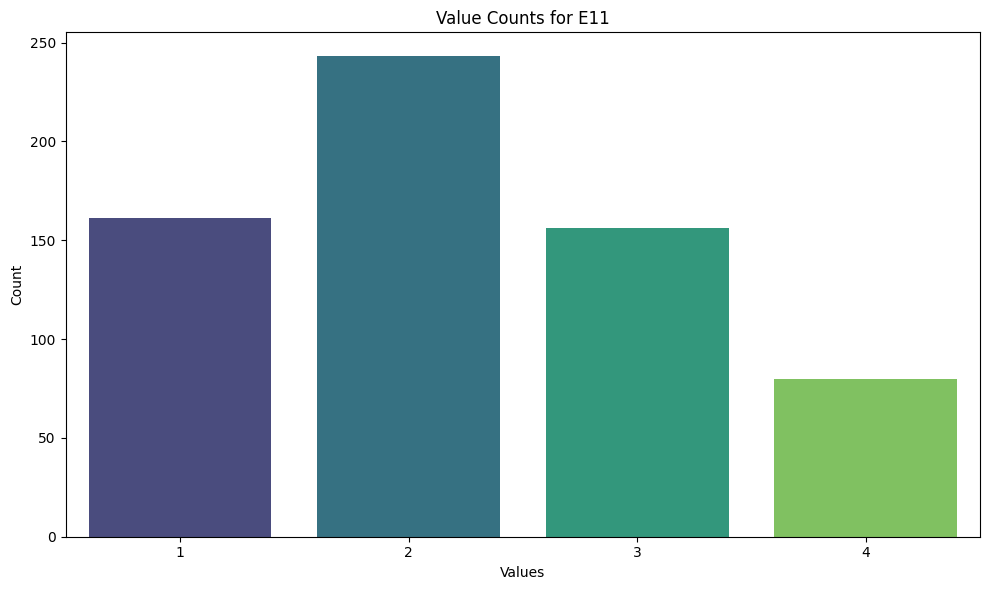

Counts for E12:
E12
4    413
3    141
2     58
1     28
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


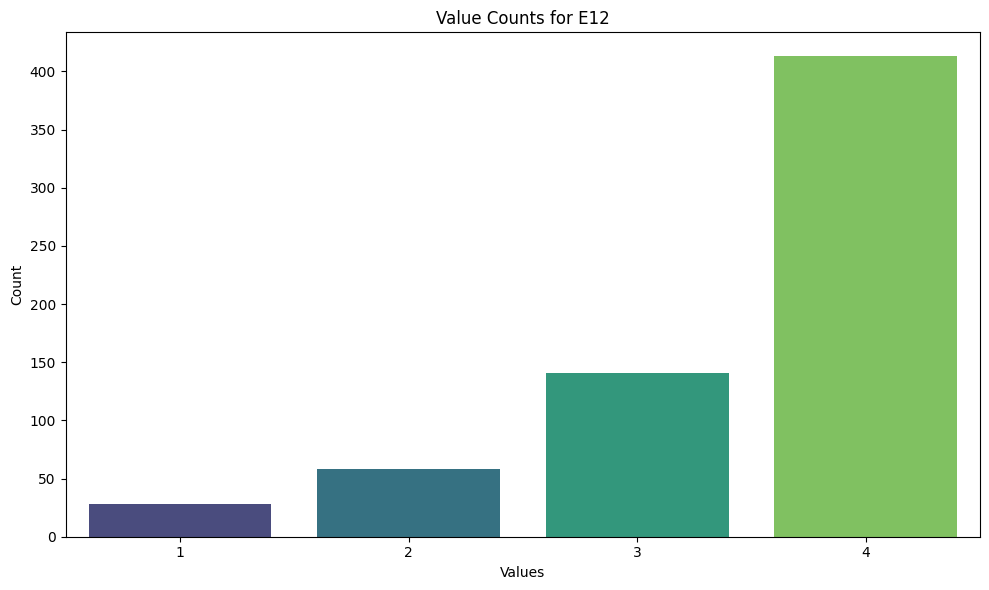

Counts for E13:
E13
1    294
3    141
2    131
4     74
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


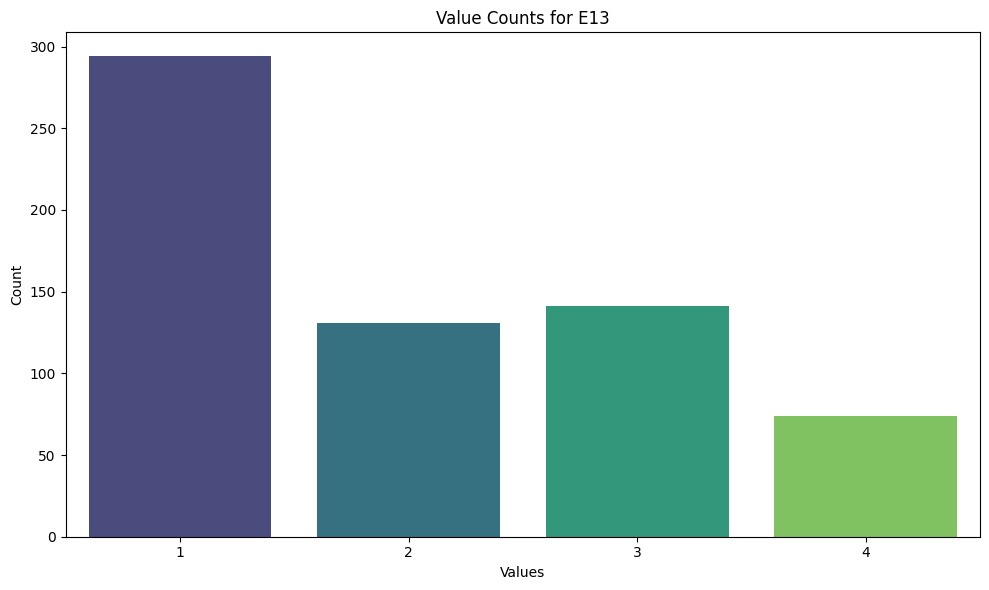

Counts for E14:
E14
2    225
3    209
1    116
4     90
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


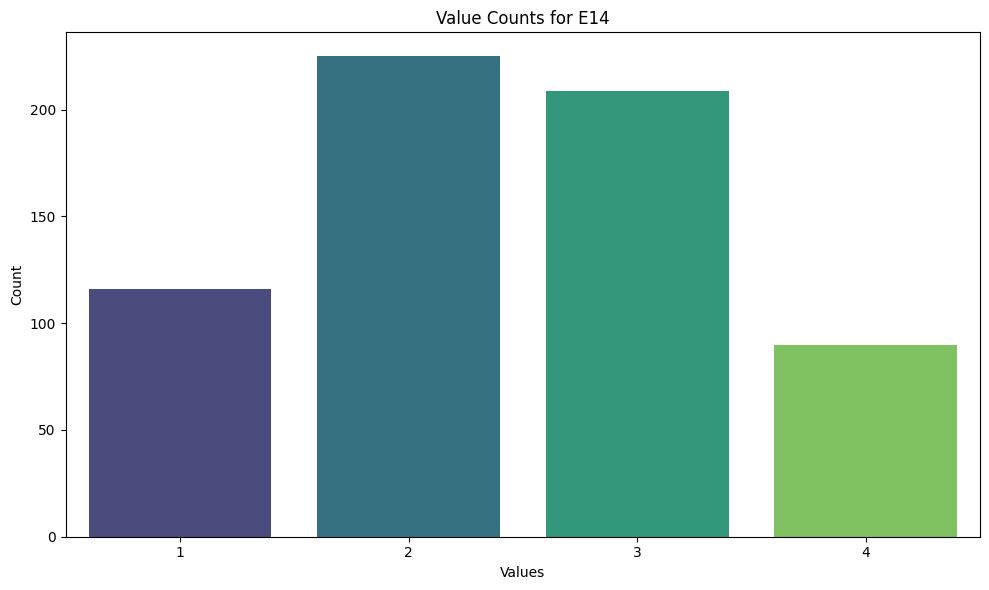

Counts for E15:
E15
3    289
2    175
4    159
1     17
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


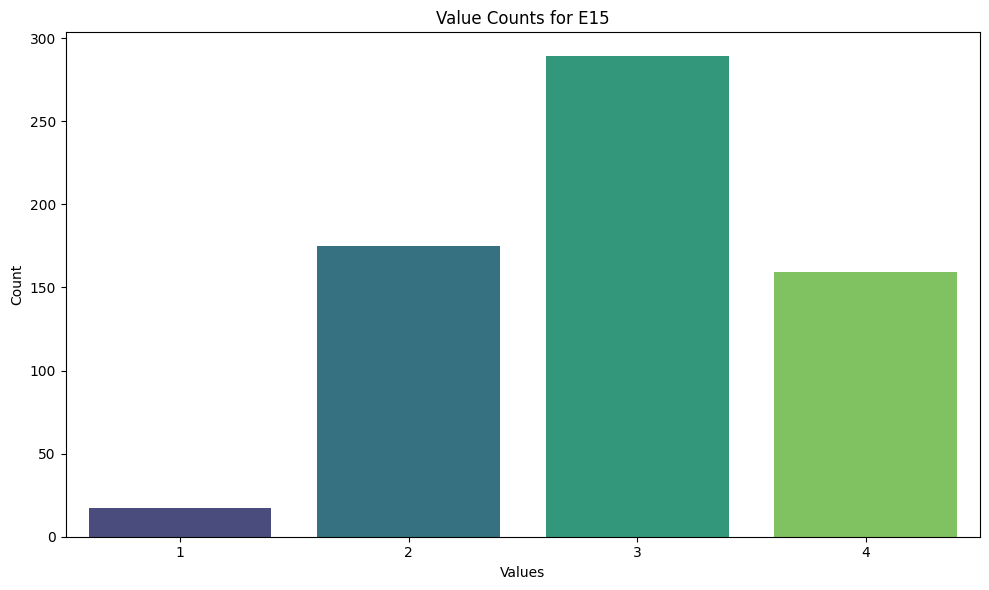

Counts for E16:
E16
4    271
3    262
2     97
1     10
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


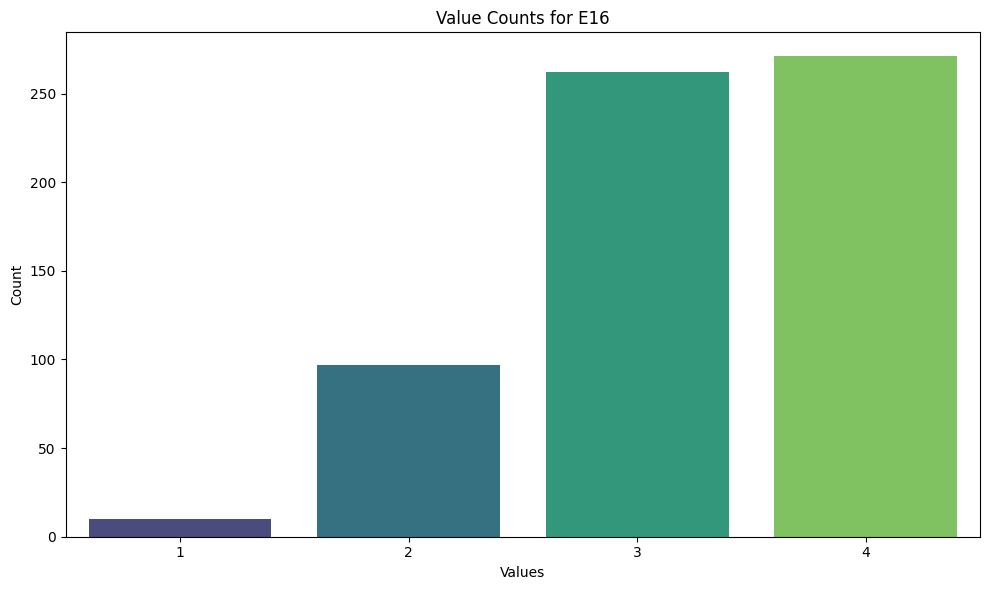

Counts for E17:
E17
2    241
3    237
4    123
1     39
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


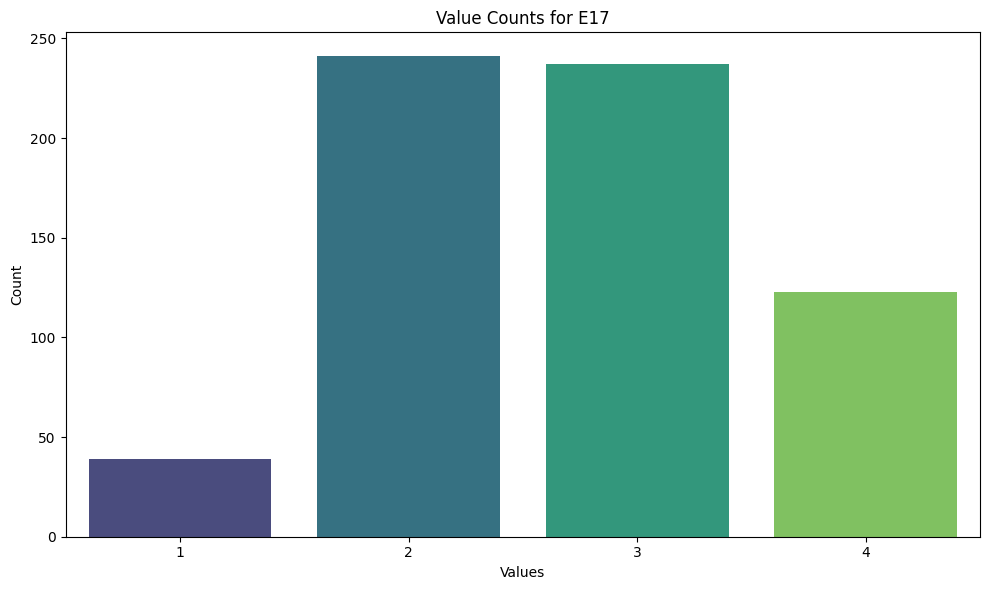

Counts for E18:
E18
2    169
3    165
1    164
4    142
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


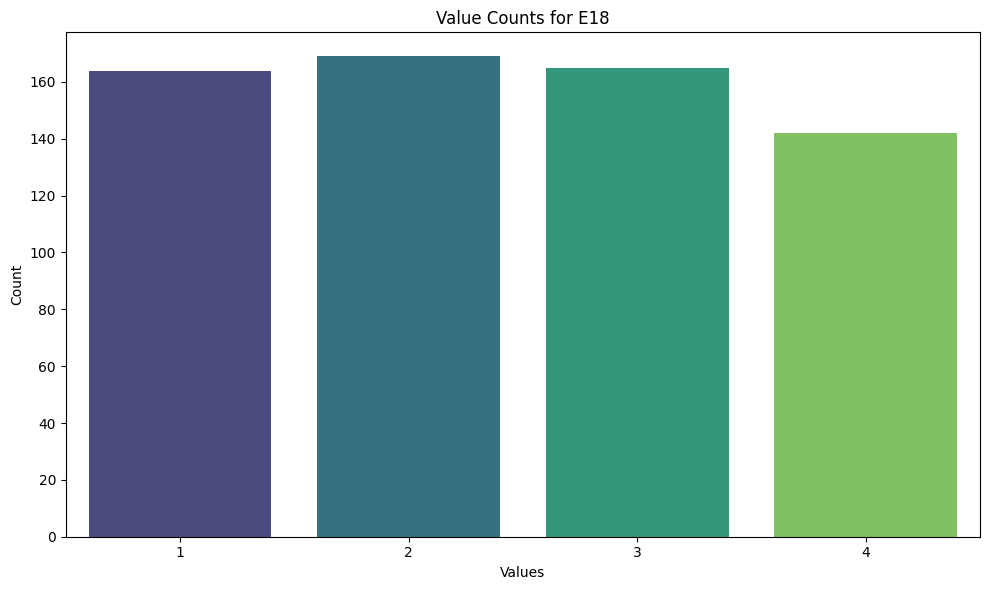

Counts for E19:
E19
3    266
2    195
4    130
1     49
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


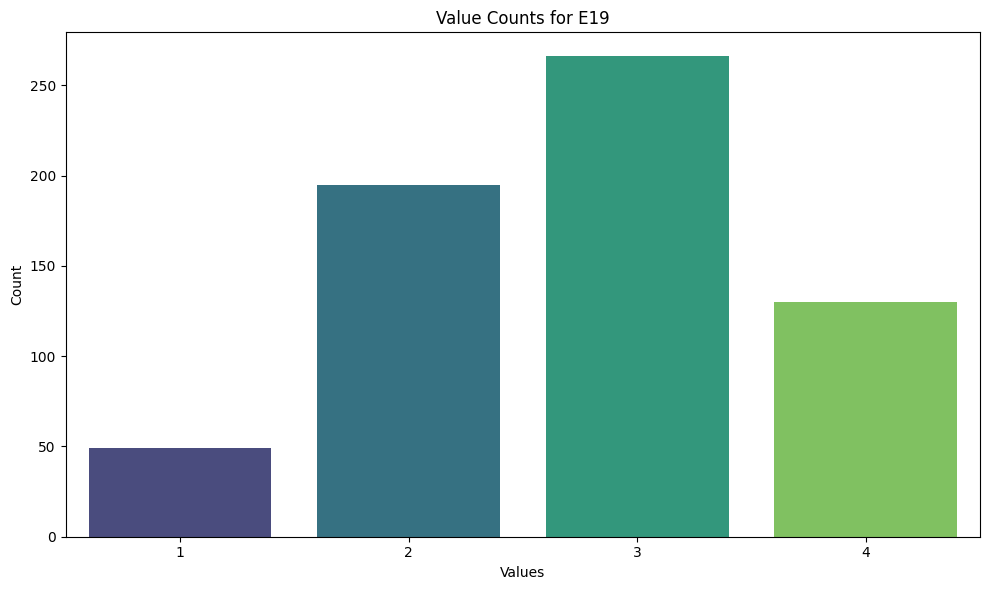

Counts for E20:
E20
4    269
3    261
2    107
1      3
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


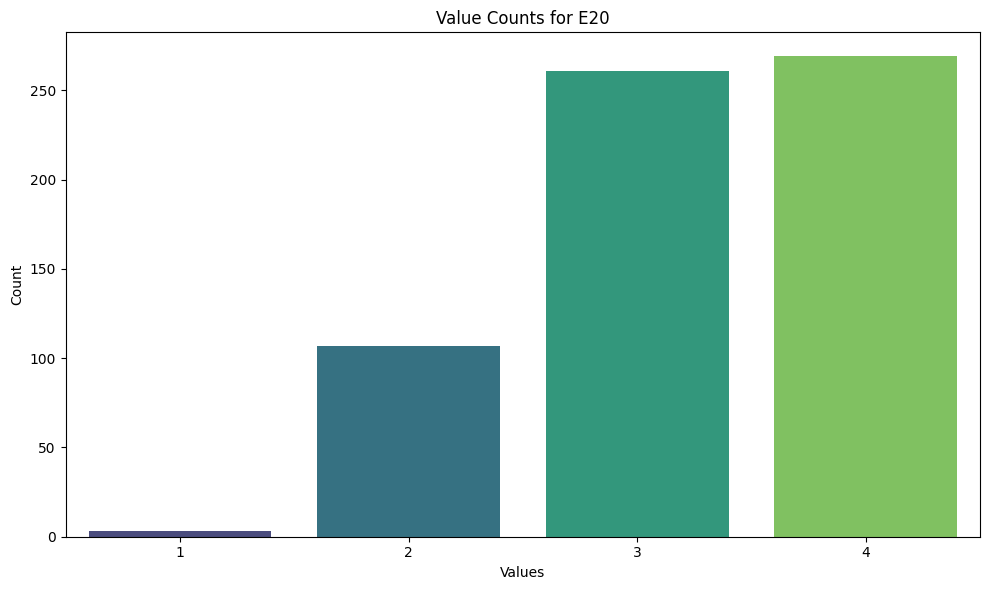

Counts for E21:
E21
4    334
3    173
2    109
1     24
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


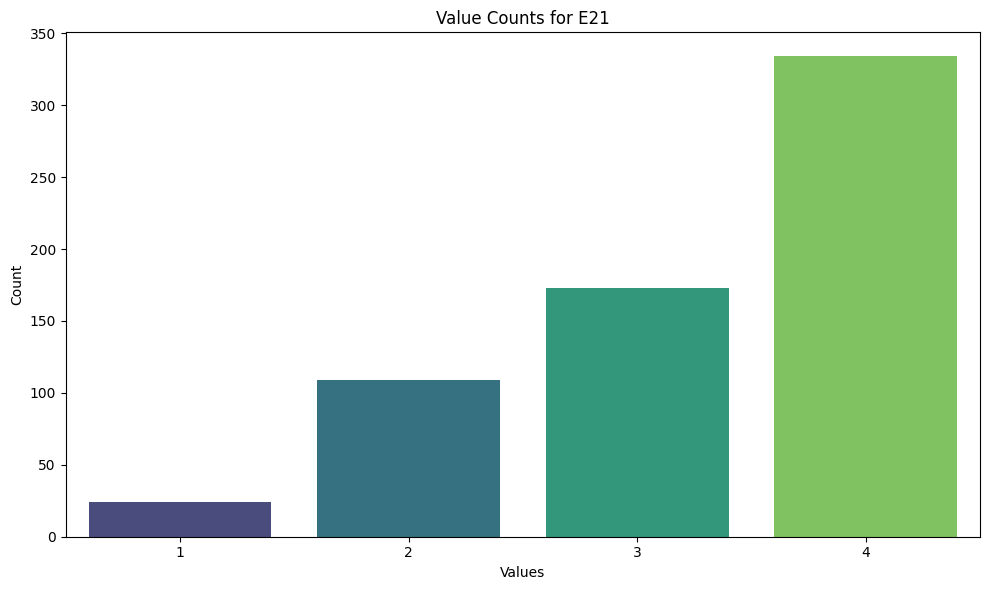

Counts for E22:
E22
3    191
2    180
4    155
1    114
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


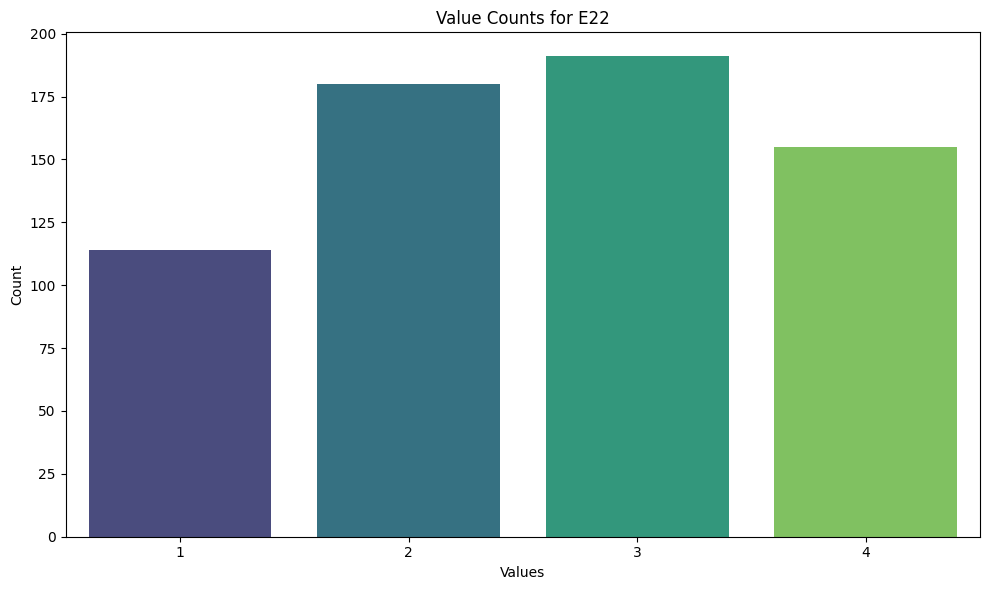

Counts for E23:
E23
2    197
3    196
1    145
4    102
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


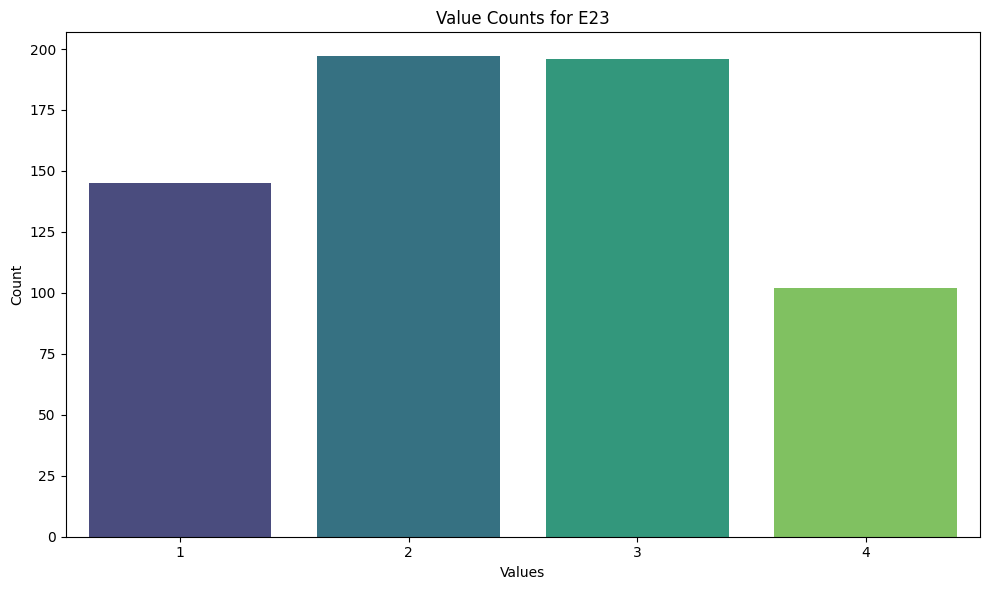

Counts for E24:
E24
2    207
3    167
1    156
4    110
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


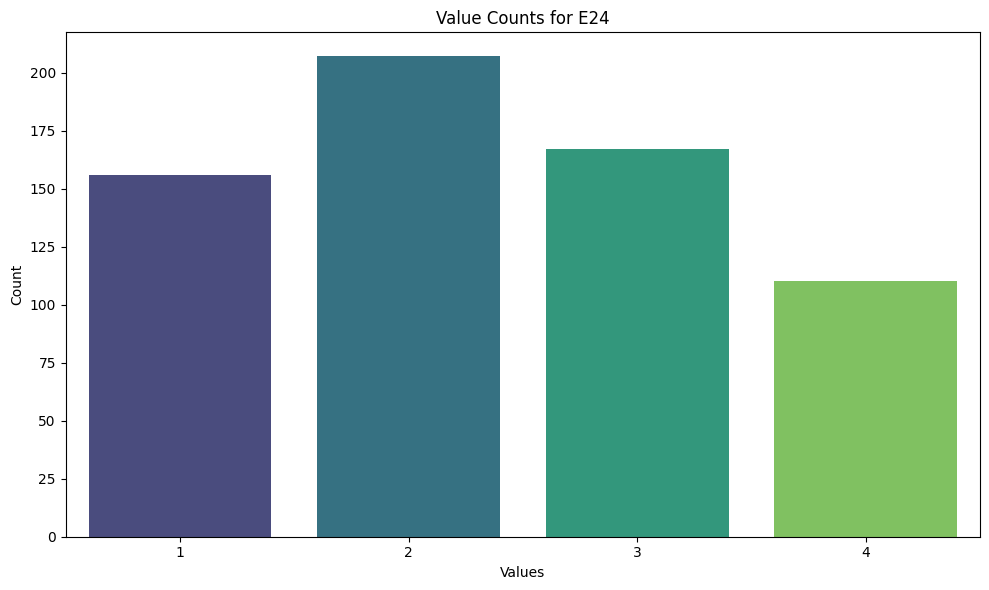

Counts for E25:
E25
4    354
3    201
2     74
1     11
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


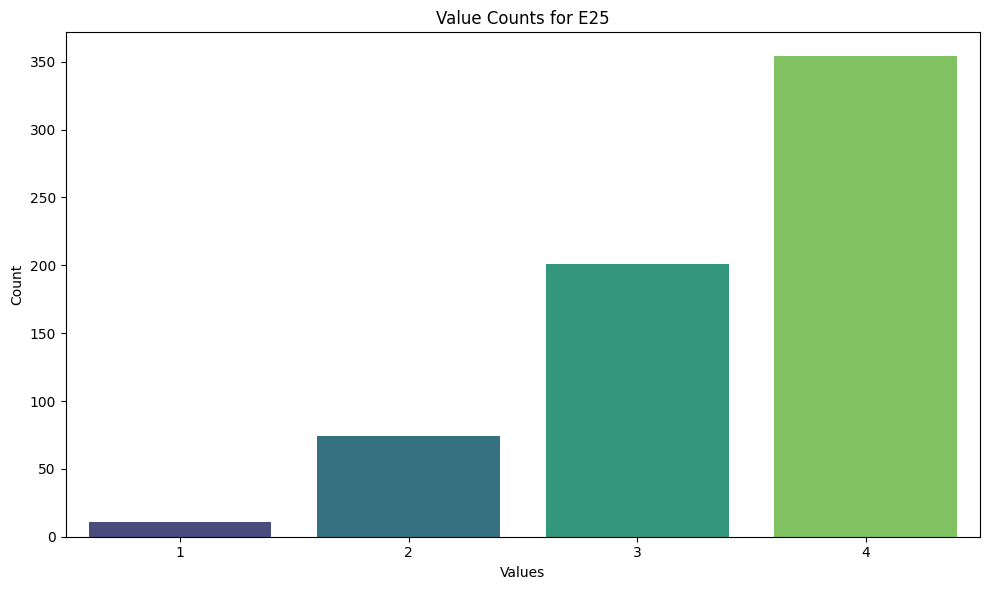

Counts for E26:
E26
4    248
3    226
2    131
1     35
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


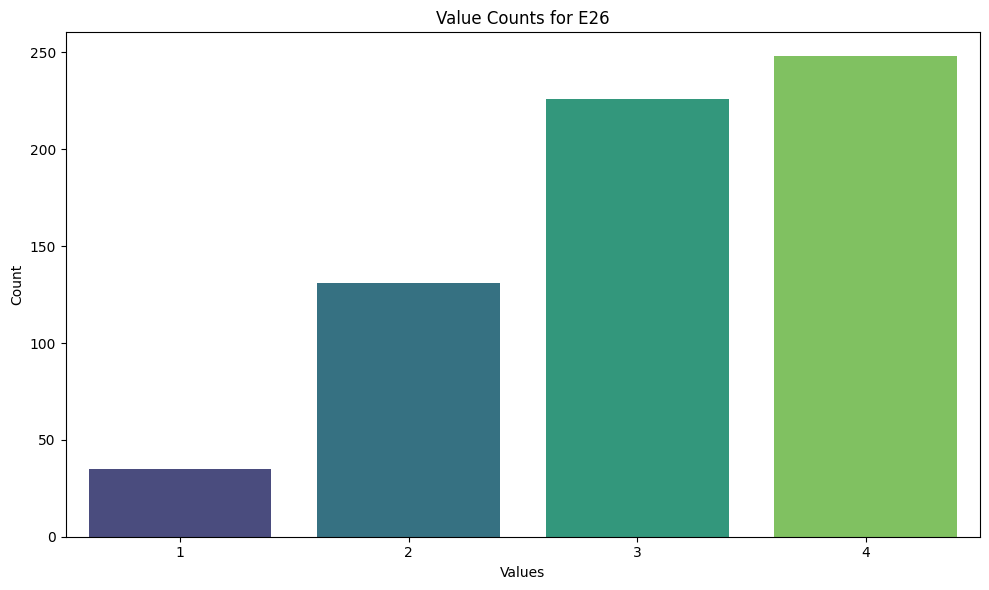

Counts for E27:
E27
3    200
2    180
4    155
1    105
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


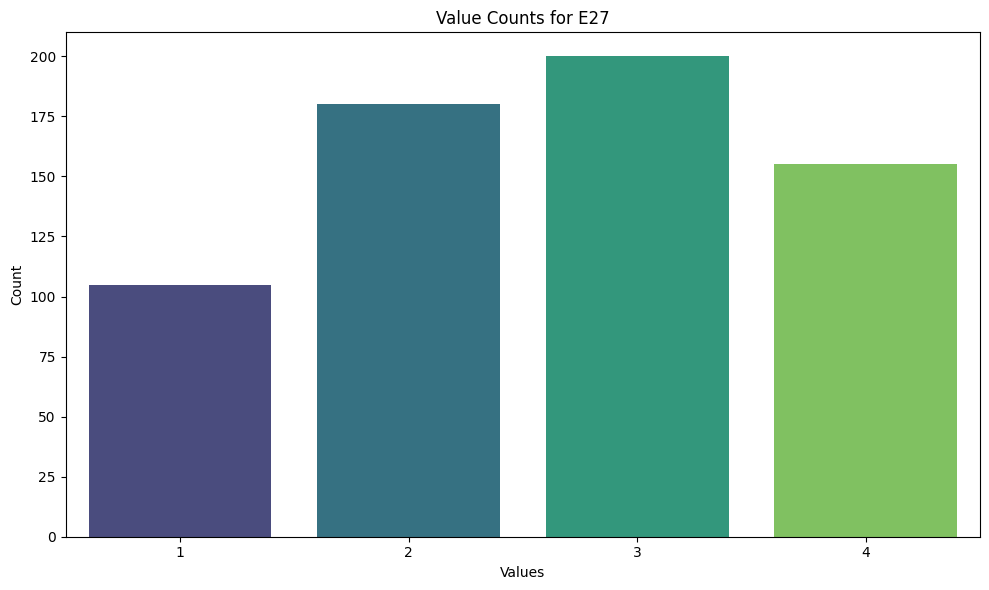

Counts for E28:
E28
4    225
3    225
2    145
1     45
Name: count, dtype: int64


<ipython-input-25-3d370e6f8236>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


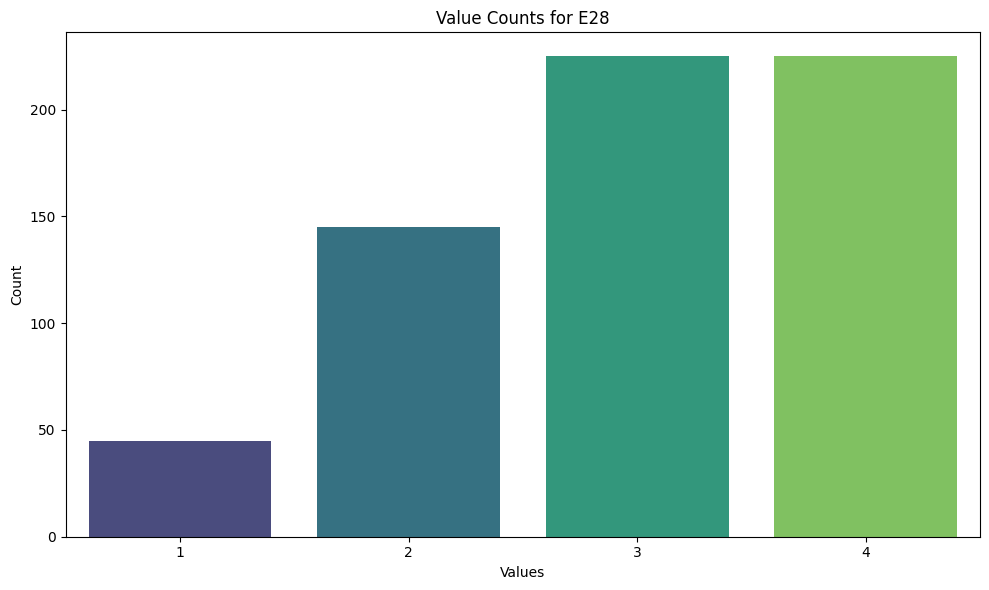

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update with your file path
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Select behavioral columns starting with 'E'
behavioral_columns = [col for col in data.columns if col.startswith('E')]

# Count values for each E-column and visualize
for col in behavioral_columns:
    value_counts = data[col].value_counts()

    # Print the counts for the current column
    print(f"Counts for {col}:")
    print(value_counts)

    # Plot the value counts
    plt.figure(figsize=(10, 6))
    sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
    plt.title(f"Value Counts for {col}")
    plt.xlabel("Values")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [28]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update with your file path
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Select behavioral columns starting with 'E'
behavioral_columns = [col for col in data.columns if col.startswith('E')]

# Aggregate value counts for all behavioral columns into a single DataFrame
behavioral_value_counts = {}

for col in behavioral_columns:
    value_counts = data[col].value_counts()
    behavioral_value_counts[col] = value_counts

# Combine all value counts into a single DataFrame
value_counts_df = pd.DataFrame(behavioral_value_counts).fillna(0).astype(int)

# Display the full table
print("Value Counts for All Behavioral Columns (E-columns):")
print(value_counts_df)

# Save the table to a CSV file for further inspection
value_counts_df.to_csv('behavioral_value_counts.csv')
print("Value counts saved to 'behavioral_value_counts.csv'.")


Value Counts for All Behavioral Columns (E-columns):
    E1   E2   E3   E4   E5   E6   E7   E8   E9  E10  ...  E19  E20  E21  E22  \
1    5   11    9   40   31   11   12   10   12    6  ...   49    3   24  114   
2  112  105  116  163  194   21   41   36   37   52  ...  195  107  109  180   
3  270  241  262  221  279   66   75   99   95  123  ...  266  261  173  191   
4  253  283  253  216  136  175  154  159  173  459  ...  130  269  334  155   
5    0    0    0    0    0  367  358  336  323    0  ...    0    0    0    0   

   E23  E24  E25  E26  E27  E28  
1  145  156   11   35  105   45  
2  197  207   74  131  180  145  
3  196  167  201  226  200  225  
4  102  110  354  248  155  225  
5    0    0    0    0    0    0  

[5 rows x 28 columns]
Value counts saved to 'behavioral_value_counts.csv'.


In [31]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update with your file path
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Select behavioral columns starting with 'E'
behavioral_columns = [col for col in data.columns if col.startswith('E')]

# Aggregate value counts for all behavioral columns into a single DataFrame
behavioral_value_counts = {}

for col in behavioral_columns:
    value_counts = data[col].value_counts()
    behavioral_value_counts[col] = value_counts

# Combine all value counts into a single DataFrame
value_counts_df = pd.DataFrame(behavioral_value_counts).fillna(0).astype(int)

# Display the full table
print("Value Counts for All Behavioral Columns (E-columns):")
print(value_counts_df)

# Save the table to a CSV file for further inspection
value_counts_df.to_csv('/content/drive/My Drive/data_science/behavioral_value_counts.csv', index=True)
print("Value counts saved to 'behavioral_value_counts.csv'.")


Value Counts for All Behavioral Columns (E-columns):
    E1   E2   E3   E4   E5   E6   E7   E8   E9  E10  ...  E19  E20  E21  E22  \
1    5   11    9   40   31   11   12   10   12    6  ...   49    3   24  114   
2  112  105  116  163  194   21   41   36   37   52  ...  195  107  109  180   
3  270  241  262  221  279   66   75   99   95  123  ...  266  261  173  191   
4  253  283  253  216  136  175  154  159  173  459  ...  130  269  334  155   
5    0    0    0    0    0  367  358  336  323    0  ...    0    0    0    0   

   E23  E24  E25  E26  E27  E28  
1  145  156   11   35  105   45  
2  197  207   74  131  180  145  
3  196  167  201  226  200  225  
4  102  110  354  248  155  225  
5    0    0    0    0    0    0  

[5 rows x 28 columns]
Value counts saved to 'behavioral_value_counts.csv'.


In [34]:
# Load the uploaded value counts data
file_path = '/content/drive/My Drive/data_science/behavioral_value_counts.csv'
value_counts_df = pd.read_csv(file_path, index_col=0)

# Rank each column by its highest value and highlight the maximum for each column
ranked_df = value_counts_df.idxmax().to_frame(name='Highest Value Category')
ranked_df['Highest Value'] = value_counts_df.max()

# Rank columns based on the highest value across categories
ranked_df = ranked_df.sort_values(by='Highest Value', ascending=False)

# Display the ranked DataFrame to the user
import ace_tools as tools  # Assuming ace_tools for better table display
tools.display_dataframe_to_user(name="Ranked Behavioral Features", dataframe=ranked_df)

# Display the ranked DataFrame in the console
print("Ranked Behavioral Features:")
print(ranked_df)

# Save the ranked DataFrame to a CSV file for external inspection
ranked_df.to_csv('ranked_behavioral_features.csv')
print("Ranked features saved to 'ranked_behavioral_features.csv'.")


ModuleNotFoundError: No module named 'ace_tools'

In [35]:
import pandas as pd

# Load the uploaded value counts data
file_path = '/content/drive/My Drive/data_science/behavioral_value_counts.csv'
value_counts_df = pd.read_csv(file_path, index_col=0)

# Rank each column by its highest value and highlight the maximum for each column
ranked_df = value_counts_df.idxmax().to_frame(name='Highest Value Category')
ranked_df['Highest Value'] = value_counts_df.max()

# Rank columns based on the highest value across categories
ranked_df = ranked_df.sort_values(by='Highest Value', ascending=False)

# Display the ranked DataFrame in the console
print("Ranked Behavioral Features:")
print(ranked_df)

# Save the ranked DataFrame to a CSV file for external inspection
ranked_df.to_csv('ranked_behavioral_features.csv')
print("Ranked features saved to 'ranked_behavioral_features.csv'.")


Ranked Behavioral Features:
     Highest Value Category  Highest Value
E10                       4            459
E12                       4            413
E6                        5            367
E7                        5            358
E25                       4            354
E8                        5            336
E21                       4            334
E9                        5            323
E13                       1            294
E15                       3            289
E2                        4            283
E5                        3            279
E16                       4            271
E1                        3            270
E20                       4            269
E19                       3            266
E3                        3            262
E26                       4            248
E11                       2            243
E17                       2            241
E14                       2            225
E28                       